# Encoder-Only Transformers for Relational Reasoning

## Baseline Models

Before implementing transformers, let's start with simpler architectures to understand why ranking is difficult for traditional sequence models.

Here, we will implement:
- MLP
- RNN
- LSTM


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, TensorDataset, DataLoader, random_split

In [2]:
df = pd.read_csv("ranking_dataset.csv")
X = df.iloc[:, :10]
y = df.iloc[:, 10:]

class RankingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.to_numpy(), dtype=torch.float32)
        self.y = torch.tensor(y.to_numpy(), dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = RankingDataset(X, y)

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)
test_loader  = DataLoader(test_ds, batch_size=32)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
# MLP

class MLP(nn.Module):
    def __init__(self, seq_len, neu_num=256):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(seq_len, neu_num),
            nn.ReLU(),
            nn.Linear(neu_num, neu_num),
            nn.ReLU(),
            nn.Linear(neu_num, seq_len ** 2) # for each token, the probability of possible ranks
        )
        self.seq_len = seq_len

    def forward(self, X):
        # X: (batch_size, seq_len)

        output = self.network(X)
        output = output.view(-1, self.seq_len, self.seq_len)

        return output


# RNN
class RNN(nn.Module):
    def __init__(self, seq_len, hidden_size=128):
        super().__init__()

        self.rnn = nn.RNN(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.layer = nn.Linear(hidden_size, seq_len)
        self.seq_len = seq_len

    def forward(self, X):
        X = X.unsqueeze(-1) # to get (batch_size, seq_len, 1)
        out, _ = self.rnn(X)
        logits = self.layer(out)
        return logits


# LSTM
class LSTM(nn.Module):
    def __init__(self, seq_len, hidden_size=128):
        super().__init__()

        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.layer = nn.Linear(hidden_size, seq_len)
        self.seq_len = seq_len

    def forward(self, X):
        X = X.unsqueeze(-1)
        out, _ = self.lstm(X)
        logits = self.layer(out)
        return logits

In [6]:
def normalize(X, method="none"): # For later experimentation!
    if method == "zscore":
        mean = X.mean(dim=1, keepdim=True)
        std = X.std(dim=1, keepdim=True) + 1e-8
        return (X - mean) / std
    elif method == "minmax":
        min_ = X.min(dim=1, keepdim=True).values
        max_ = X.max(dim=1, keepdim=True).values
        return (X - min_) / (max_ - min_ + 1e-8)
    else:
        return X

In [7]:
def train_and_evaluate(model, dataloader, optimizer, is_transformer=False, norm="none"):
    model.to(device)
    model.train()

    lossfn = nn.CrossEntropyLoss()
    total_loss = 0.0
    correct, total = 0, 0

    for X, y in dataloader:
        X = X.to(device).float()
        X = normalize(X, norm)
        y = y.to(device).long()

        optimizer.zero_grad()

        if is_transformer:
            logits, _ = model(X)
        else:
            logits = model(X)

        loss = lossfn(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = logits.argmax(dim=-1)
        correct += (preds == y).sum().item()
        total += y.numel()

    return (total_loss / len(dataloader)), correct / total

In [ ]:
@torch.no_grad() # disables gradient calculation (LLM-inspired)
def evaluate(model, dataloader, device, is_transformer=False, norm="none"):
    model.to(device)
    model.eval()

    correct = 0
    total = 0

    for X, y in dataloader:
        X = X.to(device).float()
        X = normalize(X, norm)
        y = y.to(device)

        if is_transformer:
            logits, _ = model(X)
        else:
            logits = model(X)

        preds = logits.argmax(dim=-1)
        correct += (preds == y).sum().item()
        total += y.numel()

    return correct / total

In [ ]:
import pickle

with open("pkl_files/baseline_results.pkl", "rb") as f:
    results = pickle.load(f)

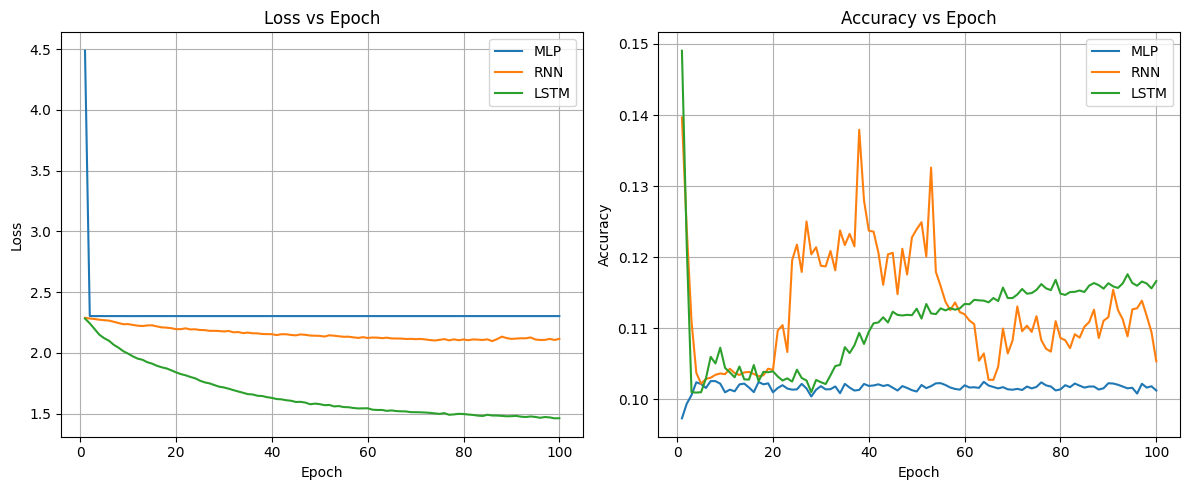

In [51]:
epochs=100
epoch_nums = range(1, epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, (losses, accuracies) in results.items():
    if name == 'Transformer': continue
    axes[0].plot(epoch_nums, losses, label=name)
    axes[1].plot(epoch_nums, accuracies, label=name)

axes[0].set_title("Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("Accuracy vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Sequential processing** - MLP processes all tokens simultaneously as a flat vector, while RNN and LSTM process one token at a time left-to-right, accumulating a hidden state. The transformer processes all tokens in parallel through self-attention, with no notion of order unless positional encodings are added.

**Long-range reasoning** - RNN and LSTM struggle with long-range reasoning due to information from early tokens getting diluted by the time the model reaches the last token. The transformer has no such limitation. Every token attends directly to every other token in a single step regardless of distance, hence the domination in the accuracy plot.

**Parallelism** - MLP and transformer are fully parallelizable since neither has sequential dependencies. RNN and LSTM must process tokens one step at a time, making them slower to train and harder to scale.

**Global context understanding** - All three baselines saturate at ~10-15% because none can form a complete global picture of the sequence. The transformer reaches ~45% and is still climbing because self-attention explicitly compares every token against every other token simultaneously.


- MLP: 0.101
- RNN: 0.105
- LSTM: 0.117

All three of our baseline models have performed very poorly and yielded just barely better results than random ranking.

This is primarily due to the fact that these 3 baseline models are sequential models. Sequential models are known to struggle with global comparisons. Since their architectures involve condensing information, which leads to loss of earlier information.

Also it is worth noting that the MLP and RNN converged extremely early. This could be due to the models hitting a performance ceiling imposed by their architecture.

In [ ]:
model_mlp = MLP(seq_len=10)
model_mlp.eval()
model_rnn = RNN(seq_len=10)
model_rnn.eval()
model_lstm = LSTM(seq_len=10)
model_lstm.eval()

print("=== Validation Accuracy ===")
for name, model in [("MLP", model_mlp), ("RNN", model_rnn), ("LSTM", model_lstm)]:
    acc = evaluate(model, val_loader, device)
    print(f"{name}: {acc:.4f}")

=== Validation Accuracy ===
MLP: 0.1093
RNN: 0.1023
LSTM: 0.0987


The validation accuracy roughly reflects the training accuracy.

In [ ]:
def test_on_length(model, seq_len, n_samples=200):
    model.to(device)
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for _ in range(n_samples):
            nums = torch.randint(0, 1000, (1, seq_len), device=device).float()
            true_ranks = torch.argsort(torch.argsort(nums, dim=1), dim=1)
            logits = model(nums)
            preds = logits.argmax(dim=-1)
            correct += (preds == true_ranks).sum().item()
            total += true_ranks.numel()
    return correct / total

# RNN and LSTM only since MLP is fixed to seq_len=10 (LLM-inspired)
for length in [10, 15, 20, 30, 50]:
    rnn_acc = test_on_length(model_rnn, length)
    lstm_acc = test_on_length(model_lstm, length)
    print(f"Seq len {length}: RNN={rnn_acc:.3f}, LSTM={lstm_acc:.3f}")

Seq len 10: RNN=0.102, LSTM=0.102
Seq len 15: RNN=0.068, LSTM=0.067
Seq len 20: RNN=0.051, LSTM=0.050
Seq len 30: RNN=0.035, LSTM=0.033
Seq len 50: RNN=0.021, LSTM=0.020


It's apparent that the accuracy drops as length increases. This goes to show that performance degrades with longer sequences.

In [ ]:
import time

def time_model(model, dataloader, device, epochs=10): # (LLM-inspired)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    start = time.time()
    for _ in range(epochs):
        train_and_evaluate(model, dataloader, optimizer)
    return (time.time() - start) / epochs 

print("\n=== Computational Efficiency (average number of seconds/epoch) ===")
for name, model in [("MLP",  MLP(seq_len=10, neu_num=128)),
                    ("RNN",  RNN(seq_len=10)),
                    ("LSTM", LSTM(seq_len=10))]:
    t = time_model(model, train_loader, device)
    num_params = sum(p.numel() for p in model.parameters()) # (LLM-inspired)
    print(f"{name}: {t:.4f}s/epoch  |  {num_params:,} parameters")


=== Computational Efficiency (average number of seconds/epoch) ===
MLP: 0.5084s/epoch  |  30,820 parameters
RNN: 0.5727s/epoch  |  18,058 parameters
LSTM: 0.5614s/epoch  |  68,362 parameters


The MLP is the fastest despite having more parameters than the RNN, since it uses only matrix multiplications, allowing full parallelization. The LSTM is the slowest due to its four gating operations per timestep, and unlike the MLP, both recurrent models must process tokens one step at a time, preventing parallelization.

## Encoder-Only Transformer

Since our input itself is numbers, we don't have to bother by making vector embeddings.

```d_model``` size of the hidden vector representing each token
```num_heads``` number of parallel attention heads working
```d_k``` dimension of the keys

$$d_k = \frac{d_{model}}{num_{heads}}$$

In [ ]:
def Attention(Q, K, V, mask=None): # mask is for masked self-attention
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(d_k) # QK^T / sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))

    weights = torch.nn.functional.softmax(scores, dim=-1) # softmax(QK^T / sqrt(d_k))
    return torch.matmul(weights, V), weights # softmax(QK^T / sqrt(d_k)) V
    

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # self.W_Qs = nn.ModuleList([nn.Linear(d_model, d_k) for _ in range(num_heads)]) # Normal Python lists don't register parameters, so we use ModuleList
        # self.W_Ks = nn.ModuleList([nn.Linear(d_model, d_k) for _ in range(num_heads)])
        # self.W_Vs = nn.ModuleList([nn.Linear(d_model, d_v) for _ in range(num_heads)])
        # The above implementation uses a sequential loop, so is slower. The below implementation uses batched matmul

        # (LLM-inspired)
        self.W_Q = nn.Linear(d_model, d_model) # concatenation of all the heads since d_model = h * d_k
        self.W_K = nn.Linear(d_model, d_model) # this computes all h heads simultaneously and later, we will simply split it
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)

    def split_heads(self, X):
        batch_size, seq_len, _ = X.size() # _ is d_model
        return X.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2) # transpose to bring heads to 2nd axis

    def merge_heads(self, X):
        batch_size, _, seq_len, _ = X.size()
        return X.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
    
    def forward(self, query, key, value, mask=None):
        Q = self.W_Q(query) # applying the linear transformation of W_Q matrix onto query
        K = self.W_K(key)
        V = self.W_V(value)

        Q = self.split_heads(Q)
        K = self.split_heads(K)
        V = self.split_heads(V)

        attn_output, attn_weights = Attention(Q, K, V, mask)

        output = self.merge_heads(attn_output)
        output = self.W_O(output)

        return output, attn_weights

In [16]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ffn):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(d_model, d_ffn),
            nn.ReLU(),
            nn.Linear(d_ffn, d_model)
        )

    def forward(self, X):
        return self.network(X)

In [ ]:
class Encoder(nn.Module):
    def __init__(self, d_model, num_heads, d_ffn):
        super().__init__()

        self.attn = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, d_ffn)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, X):
        # SELF-ATTENTION -> ADD + NORMALIZE -> FFN -> ADD + NORMALIZE
        attn_out, attn_weights = self.attn(X, X, X)
        X = self.norm1(X + attn_out)
        ffn_out = self.ffn(X)
        X = self.norm2(X + ffn_out)

        return X, attn_weights # attn_weights for future attention heat map usage


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        # position = np.arange(0, max_len).unsqueeze(1)
        # div_term = np.exp(np.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))

        # Mixing numpy and torch here causes a dtype error (LLM-inspired)

        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))        

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0)) # Positional Encodings are not trainable, so we don't want gradient updates, but we do want to store it. (LLM-inspired)

    def forward(self, X):
        return (X + self.pe[:, :X.size(1)])

In [19]:
class Transformer(nn.Module):
    def __init__(self, seq_len, d_model=32, num_heads=4, d_ffn=64, num_layers=2):
        super().__init__()

        # Transformers expect vectors as inputs, but we have scalars. So we learn a projection.
        # self.input_projection = nn.Linear(1, d_model)
        self.input_projection = nn.Sequential(
            nn.Linear(1, d_model),
            nn.ReLU()
        )
        self.positional_encoding = PositionalEncoding(d_model, max_len=seq_len)

        self.encoder_layers = nn.ModuleList([Encoder(d_model, num_heads, d_ffn) for _ in range(num_layers)])

        self.classification_head = nn.Linear(d_model, seq_len) # converts each token representation into rank logits


    def forward(self, X):
        X = X.unsqueeze(-1)
        X = self.input_projection(X)
        X = self.positional_encoding(X)

        all_weights = []
        for layer in self.encoder_layers:
            X, attn_weights = layer(X)
            all_weights.append(attn_weights)

        logits = self.classification_head(X)
        return logits, all_weights

In [ ]:
with open("pkl_files/baseline_results.pkl", "rb") as f:
    results = pickle.load(f)

transformer_data = results['Transformer']
transformer_losses, transformer_accuracies = transformer_data[0], transformer_data[1]

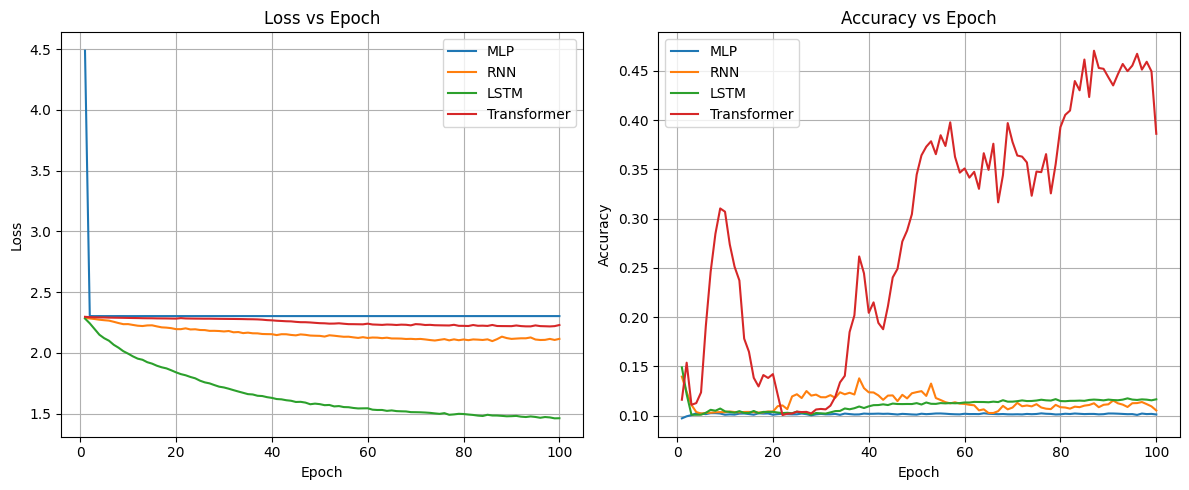

In [22]:
epochs = 100
epoch_nums = range(1, epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, (losses, accuracies) in results.items():
    axes[0].plot(epoch_nums, losses, label=name)
    axes[1].plot(epoch_nums, accuracies, label=name)

axes[0].set_title("Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("Accuracy vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
transformer = Transformer(seq_len=10, d_model=64, num_heads=4, d_ffn=128, num_layers=2)
optimizer = optim.Adam(transformer.parameters(), lr=0.0001)

epochs = 500
transformer_losses, transformer_accuracies = [], []

for epoch in range(epochs):
    loss, acc = train_and_evaluate(transformer, train_loader, optimizer, is_transformer=True)
    transformer_losses.append(loss)
    transformer_accuracies.append(acc)

    if epoch % 50 == 0:
        val_acc = evaluate(transformer, val_loader, device, is_transformer=True)
        print(f"Epoch {epoch}: loss={loss:.4f}, train_acc={acc:.4f}, val_acc={val_acc:.4f}")

print(f"\nFinal train acc: {transformer_accuracies[-1]:.4f}")
print(f"Final val acc: {evaluate(transformer, val_loader, device, is_transformer=True):.4f}")

In [24]:
trained_transformer = Transformer(seq_len=10, d_model=64, num_heads=4, d_ffn=128, num_layers=2)

trained_transformer.load_state_dict(torch.load("transformer.pth"))
trained_transformer.eval()
evaluate(trained_transformer, val_loader, device, is_transformer=True)

0.4435

## Inference, Visualization & Analysis

Input:           [45, 12, 99, 31, 67, 8, 55, 23, 88, 41]
Predicted ranks: [4, 7, 4, 4, 4, 7, 4, 1, 4, 4]
Correct ranks:   [5, 1, 9, 3, 7, 0, 6, 2, 8, 4]
Token acc:       0.10


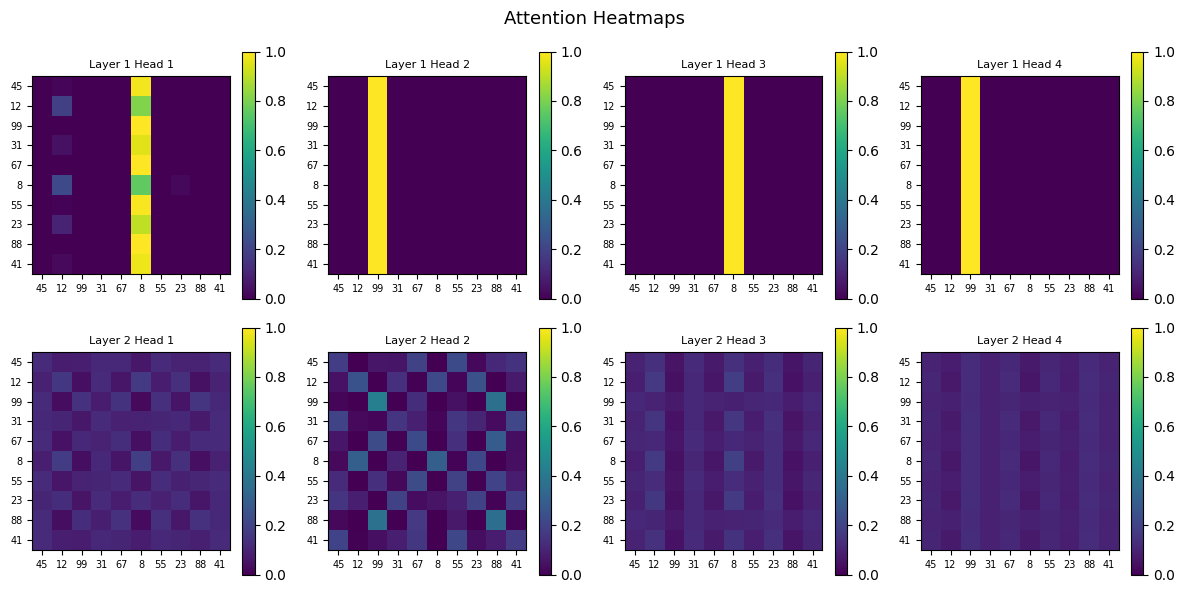

In [ ]:
def plot_attention_heatmaps(model, sequence): # (LLM-inspired)
    model.eval()
    x = torch.tensor([sequence], dtype=torch.float32).to(device)
    
    with torch.no_grad():
        logits, all_weights = model(x)
    
    predicted_ranks = logits.argmax(dim=-1).squeeze().tolist()
    true_ranks = torch.argsort(torch.argsort(torch.tensor(sequence))).tolist()
    token_acc = sum(p == t for p, t in zip(predicted_ranks, true_ranks)) / len(true_ranks)
    
    print(f"Input:           {sequence}")
    print(f"Predicted ranks: {predicted_ranks}")
    print(f"Correct ranks:   {true_ranks}")
    print(f"Token acc:       {token_acc:.2f}")

    num_layers = len(all_weights)
    num_heads = all_weights[0].shape[1]

    fig, axes = plt.subplots(num_layers, num_heads, figsize=(num_heads * 3, num_layers * 3))

    for layer_idx, weights in enumerate(all_weights):
        for head_idx in range(num_heads):
            ax = axes[layer_idx][head_idx]
            attn = weights[0, head_idx].cpu().numpy()
            im = ax.imshow(attn, cmap="viridis", vmin=0, vmax=1)
            ax.set_title(f"Layer {layer_idx+1} Head {head_idx+1}", fontsize=8)
            ax.set_xticks(range(len(sequence)))
            ax.set_yticks(range(len(sequence)))
            ax.set_xticklabels(sequence, fontsize=7)
            ax.set_yticklabels(sequence, fontsize=7)
            plt.colorbar(im, ax=ax)

    plt.suptitle("Attention Heatmaps", fontsize=13)
    plt.tight_layout()
    plt.show()

plot_attention_heatmaps(trained_transformer, [45, 12, 99, 31, 67, 8, 55, 23, 88, 41])

Let's analyze these heat maps.

In an attention heatmap:

- The columns represent the tokens being attended to (the keys)
- The rows represent the tokens doing the attending (the queries)


In the first layer, each heat map of each head has a bright column under tokens 8 and 99. This means every token in the sequence is attending heavily to 8 and 99. Which makes sense since they are the smallest and largest elements in the sequence. So, the first layer's working can be interpreted as every token asking "what is the smallest/largest value in the sequence?" 

In the second layer, unlike the first layer, each head isn't doing the same thing! Rather
- Head 1: fairly uniform attention across all tokens, the model is doing a global survey of the whole sequence
- Head 2: tokens are selectively attending to specific others, likely doing pairwise comparisons
- Head 3: block-like pattern, seems to group tokens together, possibly by value range (larger value columns have darker color)
- Head 4: similar to head 1, broad uniform attention


This two-stage behaviour mirrors how humans rank: first identify the extremes, then compare everything else relative to them. And it's fascinating that the model independently discovered this strategy just from training on ranking data!


In [ ]:
def eval_ood(model, sequences, device):
    model.eval()
    print("=== Out-of-Distribution Testing ===\n")
    for label, seq in sequences:
        X = torch.tensor([seq], dtype=torch.float32)
        X = X.to(device)
        true_ranks = torch.argsort(torch.argsort(X, dim=1), dim=1).squeeze().tolist() # .tolist converts it into Python list from PyTorch tensor
        with torch.no_grad():
            logits, _ = model(X)
        pred = logits.argmax(dim=1).squeeze().tolist()
        correct = pred == true_ranks # 
        token_acc = sum(p == t for p, t in zip(pred, true_ranks)) / len(true_ranks) # (LLM-inspired)
        print(f"{label}")
        print(f"  Input:     {seq}")
        print(f"  Predicted: {pred}")
        print(f"  Correct:   {true_ranks}")
        print(f"  Token acc: {token_acc:.2f}\n")

weird_sequences = [
    ("Sorted",          [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]),
    ("Reverse sorted",  [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]),
    ("Large values",    [1000, 900, 800, 700, 600, 500, 400, 300, 200, 100]),
    ("Repeating values",[5, 5, 5, 5, 5, 5, 5, 5, 5, 5]),
    ("Decimals",        [0.1, 0.5, 0.3, 0.9, 0.2, 0.8, 0.4, 0.7, 0.6, 0.0]),
    ("Negatives",       [-5, -1, -9, -3, -7, -2, -8, -4, -6, -10])    
]

eval_ood(trained_transformer, weird_sequences, device)

=== Out-of-Distribution Testing ===

Sorted
  Input:     [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
  Predicted: [0, 1, 1, 1, 1, 1, 1, 1, 1, 5]
  Correct:   [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Token acc: 0.20

Reverse sorted
  Input:     [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
  Predicted: [9, 8, 9, 7, 0, 9, 9, 9, 9, 0]
  Correct:   [9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
  Token acc: 0.30

Large values
  Input:     [1000, 900, 800, 700, 600, 500, 400, 300, 200, 100]
  Predicted: [0, 8, 7, 6, 5, 4, 3, 2, 1, 0]
  Correct:   [9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
  Token acc: 0.90

Repeating values
  Input:     [5, 5, 5, 5, 5, 5, 5, 5, 5, 5]
  Predicted: [0, 2, 2, 8, 2, 2, 2, 2, 2, 5]
  Correct:   [5, 4, 6, 7, 2, 3, 1, 0, 8, 9]
  Token acc: 0.10

Decimals
  Input:     [0.1, 0.5, 0.3, 0.9, 0.2, 0.8, 0.4, 0.7, 0.6, 0.0]
  Predicted: [9, 0, 0, 9, 0, 0, 0, 0, 0, 3]
  Correct:   [1, 5, 3, 9, 2, 8, 4, 7, 6, 0]
  Token acc: 0.10

Negatives
  Input:     [-5, -1, -9, -3, -7, -2, -8, -4, -6, -10]
  Predicted: [1, 9, 9, 9, 9, 9, 0, 9, 9

#### Robustness
The model is not robust, it performs reasonably on in-distribution data (~44% val acc) but breaks down on all OOD sequences. The only exception is when tested on large values (90% acc). This could be due to the fact that the training data was also in that range.

#### Failure Modes
The model seems to repeatedly predict the same rank for most tokens (9s, 1s, 2s). Also negatives and decimals completely break the model (10% acc, essentially random), because the input values fall completely outside the range seen during training. 

#### Attention Behavior
As seen in the heatmaps, layer 1 heads anchor to the min and max tokens, which works well in-distribution. But for OOD inputs like negatives or decimals, those anchors are meaningless.

Enter 10 numbers separated by spaces:
Input:           [103.0, 353.0, 393.0, 834.0, 234.0, 2325.0, 344.0, 669.0, 499.0, 875.0]
Predicted ranks: [6, 4, 6, 7, 6, 6, 4, 6, 6, 7]
Correct ranks:   [0, 3, 4, 7, 1, 9, 2, 6, 5, 8]
Token acc:       0.20


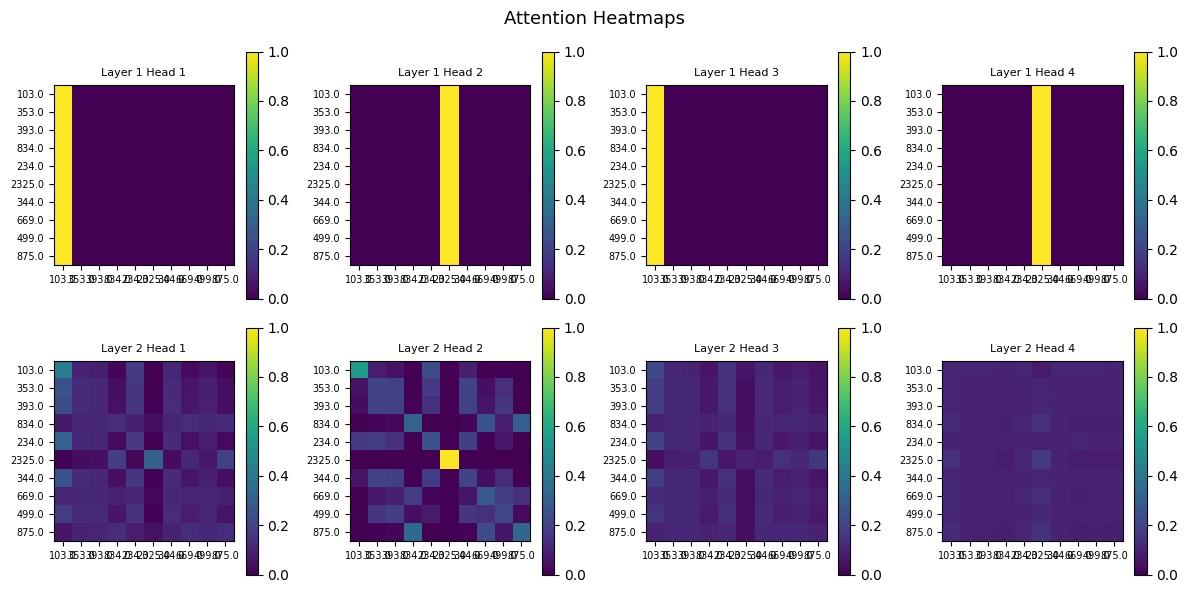

In [27]:
def demo(model, device):
    print("Enter 10 numbers separated by spaces:")
    user_input = input()
    sequence = list(map(float, user_input.strip().split()))

    if len(sequence) != 10:
        print("Please enter exactly 10 numbers.")
        return

    x = torch.tensor([sequence], dtype=torch.float32).to(device)
    true_ranks = torch.argsort(torch.argsort(x, dim=1), dim=1).squeeze().tolist()

    with torch.no_grad():
        logits, _ = model(x)
    pred = logits.argmax(dim=-1).squeeze().tolist()

    plot_attention_heatmaps(model, sequence)

demo(trained_transformer, device)

## Ablations & Experiments

In [ ]:
norm_methods = ["none", "zscore", "minmax"]
norm_results = {}

for norm in norm_methods:
    print(f"\nTraining with norm={norm}")
    model = Transformer(seq_len=10, d_model=64, num_heads=4, d_ffn=128, num_layers=2)
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5) # automatically reduces your learning rate when a monitored metric (LLM-inspired)

    best_val_acc = 0
    losses, accuracies = [], []

    for epoch in range(300):
        loss, acc = train_and_evaluate(model, train_loader, optimizer, is_transformer=True, norm=norm)
        val_acc = evaluate(model, val_loader, device, is_transformer=True, norm=norm)
        scheduler.step(loss)
        losses.append(loss)
        accuracies.append(acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"transformer_{norm}.pth") # (LLM-inspired)

        if epoch % 50 == 0:
            print(f"  Epoch {epoch}: loss={loss:.4f}, train={acc:.4f}, val={val_acc:.4f}")

    norm_results[norm] = (losses, accuracies, best_val_acc)
    print(f"  Best val acc: {best_val_acc:.4f}")


Training with norm=none
  Epoch 0: loss=2.2990, train=0.1199, val=0.1191
  Epoch 50: loss=2.2482, train=0.4320, val=0.4916
  Epoch 100: loss=2.2283, train=0.3912, val=0.4439
  Epoch 150: loss=2.2201, train=0.4796, val=0.4839
  Epoch 200: loss=2.2179, train=0.3742, val=0.4584
  Epoch 250: loss=2.1951, train=0.2951, val=0.2662
  Best val acc: 0.5514

Training with norm=zscore
  Epoch 0: loss=2.2981, train=0.1079, val=0.1171
  Epoch 50: loss=0.0815, train=0.1914, val=0.1873
  Epoch 100: loss=0.0463, train=0.1924, val=0.1899
  Epoch 150: loss=0.0301, train=0.1940, val=0.1905
  Epoch 200: loss=0.0178, train=0.1945, val=0.1897
  Epoch 250: loss=0.0238, train=0.1933, val=0.1913
  Best val acc: 0.1945

Training with norm=minmax
  Epoch 0: loss=2.3051, train=0.1398, val=0.1458
  Epoch 50: loss=0.1856, train=0.1810, val=0.1783
  Epoch 100: loss=0.1323, train=0.1837, val=0.1779
  Epoch 150: loss=0.1015, train=0.1861, val=0.1811
  Epoch 200: loss=0.0799, train=0.1875, val=0.1830
  Epoch 250: loss

In [ ]:
with open("pkl_files/normalization_results.pkl", "rb") as f:
    normalization_results = pickle.load(f)    

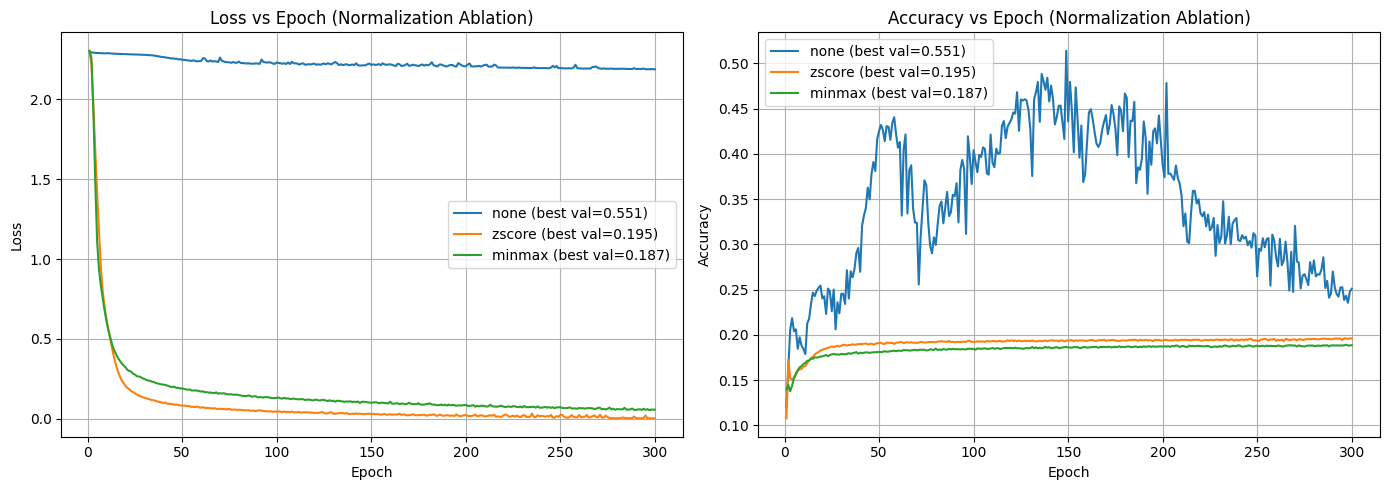

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epoch_nums = range(1, 301)

for norm, (losses, accuracies, best_val) in normalization_results.items():
    axes[0].plot(epoch_nums, losses, label=f"{norm} (best val={best_val:.3f})")
    axes[1].plot(epoch_nums, accuracies, label=f"{norm} (best val={best_val:.3f})")

axes[0].set_title("Loss vs Epoch (Normalization Ablation)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("Accuracy vs Epoch (Normalization Ablation)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

`norm=none` performs best (~51% val acc) which seems counterintuitive, but makes sense here because the training data was generated in a fixed range, so the raw values already carry meaningful magnitude information the model learned to use.

But zscore and minmax are failing badly, yielding accuracies around 19%. This is because upon normalization, the input values directly give away the relative order. The smallest number always maps to roughly the same normalized value, so the model takes a shortcut. Instead of learning to compare tokens via attention, it learns to map each normalized value directly to a rank, essentially memorizing a lookup table.

This explains the strange loss behavior. Cross entropy loss is defined as:

$$L = -\sum_{i} y_i \log(\hat{p}_i)$$

Without normalization, the model is uncertain and spreads probability roughly equally across all 10 ranks, so $\hat{p}_i = \frac{1}{10} = 0.1$ for all $i$, giving:

$$L = -\log(0.1) = 2.302$$

which closely matches what we observe. With normalization, the model becomes extremely confident in its (memorized) predictions, so $\hat{p}_i \approx 0.99$, giving:

$$L = -\log(0.99) \approx 0.01$$

For example, when we normalize an input like `[45, 12, 99, 31, 8]`, it becomes something like `[0.3, -0.5, 1.2, -0.1, -0.9]`. The smallest value always maps to the most negative number and the largest always maps to the most positive, so $\hat{p}_i$ shoots up and $L$ falls down.

Loss collapses, but accuracy doesn't improve. Because the model is confident yet wrong on anything outside its memorized lookup table. This highlights an important point: **loss measures confidence, not correctness**.

### Categorical Embeddings vs Continuous Representations

Let's explore different ways to feed numbers into our transformer, and their results.

There are three approaches to compare:
 1. Raw float - what you're already doing, just pass the number directly as a float through a linear projection. The model can see that 6 > 5 numerically.
 2. Learned projection - a slightly deeper input projection, still continuous but gives the model more capacity to represent numbers:
```
self.input_projection = nn.Sequential(
    nn.Linear(1, d_model),
    nn.ReLU(),
    nn.Linear(d_model, d_model)
)
```
 3. Categorical embedding - treat each number as a discrete token, like a word. The model has no idea 5 and 6 are related:
 ```
self.embedding = nn.Embedding(num_embeddings=1001, embedding_dim=d_model)  # 0-1000

def forward(self, X):
    X = X.long()  # must be integer indices
    X = self.embedding(X)  # (batch, seq_len, d_model)
    ...
 ```

 For this, we will make 3 different versions of our Transformer with different input representations.

In [ ]:
class TransformerRaw(nn.Module):
    def __init__(self, seq_len=10, d_model=64, num_heads=4, d_ffn=128, num_layers=2):
        super().__init__()
        self.input_projection = nn.Linear(1, d_model)
        self.positional_encoding = PositionalEncoding(d_model)
        self.encoder_layers = nn.ModuleList([Encoder(d_model, num_heads, d_ffn) for _ in range(num_layers)])
        self.classification_head = nn.Linear(d_model, seq_len)

    def forward(self, X):
        X = X.unsqueeze(-1).float()
        X = self.input_projection(X)
        X = self.positional_encoding(X)
        all_weights = []
        for layer in self.encoder_layers:
            X, w = layer(X)
            all_weights.append(w)
        return self.classification_head(X), all_weights


class TransformerProjection(nn.Module):
    def __init__(self, seq_len=10, d_model=64, num_heads=4, d_ffn=128, num_layers=2):
        super().__init__()
        self.input_projection = nn.Sequential(
            nn.Linear(1, d_model),
            nn.ReLU(),
            nn.Linear(d_model, d_model)
        )
        self.positional_encoding = PositionalEncoding(d_model)
        self.encoder_layers = nn.ModuleList([Encoder(d_model, num_heads, d_ffn) for _ in range(num_layers)])
        self.classification_head = nn.Linear(d_model, seq_len)

    def forward(self, X):
        X = X.unsqueeze(-1).float()
        X = self.input_projection(X)
        X = self.positional_encoding(X)
        all_weights = []
        for layer in self.encoder_layers:
            X, w = layer(X)
            all_weights.append(w)
        return self.classification_head(X), all_weights


class TransformerEmbedding(nn.Module):
    def __init__(self, seq_len=10, d_model=64, num_heads=4, d_ffn=128, num_layers=2, vocab_size=1001):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model)
        self.encoder_layers = nn.ModuleList([Encoder(d_model, num_heads, d_ffn) for _ in range(num_layers)])
        self.classification_head = nn.Linear(d_model, seq_len)

    def forward(self, X):
        X = X.long() # (LLM-inspired)
        X = self.embedding(X)
        X = self.positional_encoding(X)
        all_weights = []
        for layer in self.encoder_layers:
            X, w = layer(X)
            all_weights.append(w)
        return self.classification_head(X), all_weights

In [ ]:
torch.manual_seed(42)

repr_models = {
    "raw_float": TransformerRaw(),
    "learned_proj": TransformerProjection(),
    "categorical_emb": TransformerEmbedding(),
}

repr_results = {}

for name, model in repr_models.items():
    print(f"\nTraining {name}")
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)
    best_val_acc = 0
    losses, accuracies = [], []

    for epoch in range(300):
        loss, acc = train_and_evaluate(model, train_loader, optimizer, is_transformer=True)
        val_acc = evaluate(model, val_loader, device, is_transformer=True)
        scheduler.step(loss)
        losses.append(loss)
        accuracies.append(acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"{name}_best.pth")

        if epoch % 50 == 0:
            print(f"  Epoch {epoch}: loss={loss:.4f}, train={acc:.4f}, val={val_acc:.4f}")

    repr_results[name] = (losses, accuracies, best_val_acc)
    print(f"  Best val acc: {best_val_acc:.4f}")

In [ ]:
with open("pkl_files/repr_results.pkl", "rb") as f:
    repr_results = pickle.load(f)

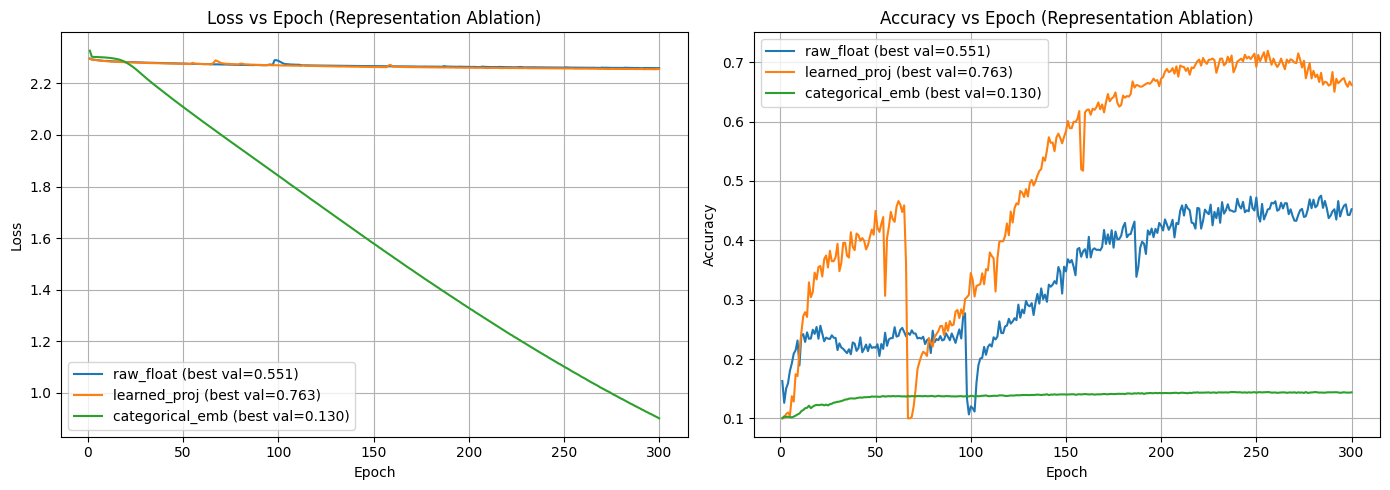

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epoch_nums = range(1, 301)

for name, (losses, accuracies, best_val) in repr_results.items():
    axes[0].plot(epoch_nums, losses, label=f"{name} (best val={best_val:.3f})")
    axes[1].plot(epoch_nums, accuracies, label=f"{name} (best val={best_val:.3f})")

axes[0].set_title("Loss vs Epoch (Representation Ablation)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("Accuracy vs Epoch (Representation Ablation)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Learned projection (76.3%)** clearly performs the best. The additional non-linearity gives the model a clearer representation of each number before attention, making comparisons easier. **Raw float (55.1%)** works but is limited by the single linear projection's capacity. **Categorical embedding (13%)** completely fails since it treats numbers as unrelated symbols with no notion of magnitude. The dwindling loss for categorical embedding is the same phenomenon observed in the normalization ablation.

In [37]:
class TransformerWoPE(nn.Module):
    def __init__(self, seq_len, d_model=64, num_heads=4, d_ffn=128, num_layers=2):
        super().__init__()
        self.input_projection = nn.Sequential(
            nn.Linear(1, d_model),
            nn.ReLU(),
            nn.Linear(d_model, d_model)
        )
        self.encoder_layers = nn.ModuleList([Encoder(d_model, num_heads, d_ffn) for _ in range(num_layers)])
        self.classification_head = nn.Linear(d_model, seq_len)

    def forward(self, X):
        X = X.unsqueeze(-1).float()
        X = self.input_projection(X)
        all_weights = []
        for layer in self.encoder_layers:
            X, w = layer(X)
            all_weights.append(w)
        return self.classification_head(X), all_weights

In [ ]:
torch.manual_seed(42)

pe_models = {
    "with_PE": Transformer(seq_len=10, d_model=64, num_heads=4, d_ffn=128, num_layers=2),
    "no_PE": TransformerWoPE(seq_len=10, d_model=64, num_heads=4, d_ffn=128, num_layers=2),
}

pe_results = {}

for name, model in pe_models.items():
    print(f"\nTraining {name}")
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)
    best_val_acc = 0
    losses, accuracies = [], []

    for epoch in range(300):
        loss, acc = train_and_evaluate(model, train_loader, optimizer, is_transformer=True)
        val_acc = evaluate(model, val_loader, device, is_transformer=True)
        scheduler.step(loss)
        losses.append(loss)
        accuracies.append(acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"{name}_best.pth")

        if epoch % 50 == 0:
            print(f"  Epoch {epoch}: loss={loss:.4f}, train={acc:.4f}, val={val_acc:.4f}")

    pe_results[name] = (losses, accuracies, best_val_acc)
    print(f"  Best val acc: {best_val_acc:.4f}")


Training with_PE
  Epoch 0: loss=2.2967, train=0.1513, val=0.1381
  Epoch 50: loss=2.2685, train=0.2602, val=0.2133
  Epoch 100: loss=2.2576, train=0.4059, val=0.3555
  Epoch 150: loss=2.2285, train=0.4686, val=0.4587
  Epoch 200: loss=2.2109, train=0.5480, val=0.4892
  Epoch 250: loss=2.2075, train=0.5436, val=0.5647
  Best val acc: 0.6069

Training no_PE
  Epoch 0: loss=2.2962, train=0.1000, val=0.1000
  Epoch 50: loss=2.2764, train=0.3895, val=0.2953
  Epoch 100: loss=2.2894, train=0.2538, val=0.2393
  Epoch 150: loss=2.2656, train=0.3653, val=0.4078
  Epoch 200: loss=2.2618, train=0.3764, val=0.4043
  Epoch 250: loss=2.2593, train=0.3896, val=0.3447
  Best val acc: 0.5220


In [ ]:
with open("pkl_files/pe_results.pkl", "rb") as f:
    pe_results = pickle.load(f)

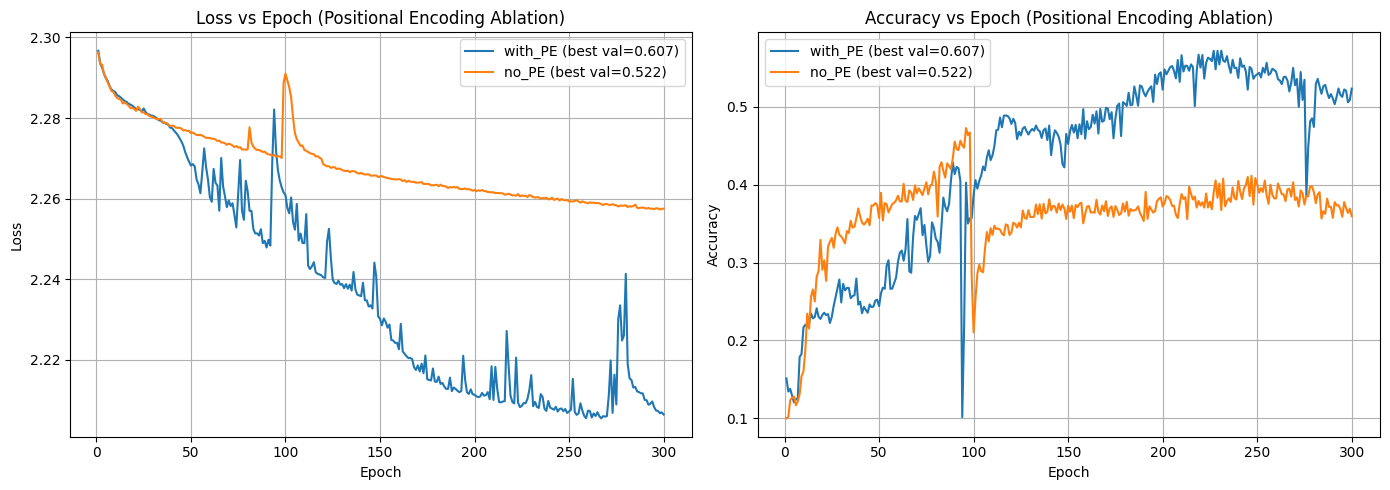

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epoch_nums = range(1, 301)

for name, (losses, accuracies, best_val) in pe_results.items():
    axes[0].plot(epoch_nums, losses, label=f"{name} (best val={best_val:.3f})")
    axes[1].plot(epoch_nums, accuracies, label=f"{name} (best val={best_val:.3f})")

axes[0].set_title("Loss vs Epoch (Positional Encoding Ablation)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("Accuracy vs Epoch (Positional Encoding Ablation)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [48]:
vals = df.iloc[:, :10]
print(vals.mean())


val_0    500.5372
val_1    506.6235
val_2    501.3963
val_3    501.4239
val_4    493.8173
val_5    495.8375
val_6    501.6163
val_7    505.3141
val_8    500.3617
val_9    500.0257
dtype: float64


The model can still rank because the values themselves contain all the information needed. The rank of the number is determined by its value, not where it is relative to other numbers. For this task, whether we use positional encoding or not should not alter the model's performance. Yet, it does. Using positional encoding seems to yield a better accuracy, that too, by a decent margin probably due to our training data having some imperfections. Certain positions might slightly favor certain value ranges as shown above.

In [41]:
torch.manual_seed(42)

depth_models = {
    "1-layer": Transformer(seq_len=10, d_model=64, num_heads=4, d_ffn=128, num_layers=1),
    "2-layer": Transformer(seq_len=10, d_model=64, num_heads=4, d_ffn=128, num_layers=2),
    "4-layer": Transformer(seq_len=10, d_model=64, num_heads=4, d_ffn=128, num_layers=4),
}

depth_results = {}

for name, model in depth_models.items():
    print(f"\nTraining {name} | params: {sum(p.numel() for p in model.parameters()):,}")
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)
    best_val_acc = 0
    losses, accuracies, val_accuracies = [], [], []

    for epoch in range(300):
        loss, acc = train_and_evaluate(model, train_loader, optimizer, is_transformer=True)
        val_acc = evaluate(model, val_loader, device, is_transformer=True)
        scheduler.step(loss)
        losses.append(loss)
        accuracies.append(acc)
        val_accuracies.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"depth_{name}_best.pth")

        if epoch % 50 == 0:
            print(f"  Epoch {epoch}: loss={loss:.4f}, train={acc:.4f}, val={val_acc:.4f}")

    depth_results[name] = (losses, accuracies, val_accuracies, best_val_acc)
    print(f"  Best val acc: {best_val_acc:.4f}")


Training 1-layer | params: 34,250
  Epoch 0: loss=2.2991, train=0.0839, val=0.1000
  Epoch 50: loss=2.2863, train=0.1002, val=0.1002
  Epoch 100: loss=2.2699, train=0.1832, val=0.1941
  Epoch 150: loss=2.2610, train=0.1086, val=0.1076
  Epoch 200: loss=2.2603, train=0.2556, val=0.2401
  Epoch 250: loss=2.2594, train=0.2414, val=0.2393
  Best val acc: 0.3461

Training 2-layer | params: 67,722
  Epoch 0: loss=2.2979, train=0.1020, val=0.1001
  Epoch 50: loss=2.2773, train=0.1003, val=0.1010
  Epoch 100: loss=2.2467, train=0.5388, val=0.5215
  Epoch 150: loss=2.2194, train=0.4718, val=0.4244
  Epoch 200: loss=2.2106, train=0.5575, val=0.5346
  Epoch 250: loss=2.2027, train=0.4942, val=0.3782
  Best val acc: 0.6140

Training 4-layer | params: 134,666
  Epoch 0: loss=2.2961, train=0.1000, val=0.1000
  Epoch 50: loss=2.2375, train=0.4298, val=0.3211
  Epoch 100: loss=2.2132, train=0.4834, val=0.5124
  Epoch 150: loss=2.0517, train=0.2220, val=0.2570
  Epoch 200: loss=0.1224, train=0.1935, v

In [ ]:
with open("pkl_files/repr_results.pkl", "rb") as f:
    repr_results = pickle.load(f)

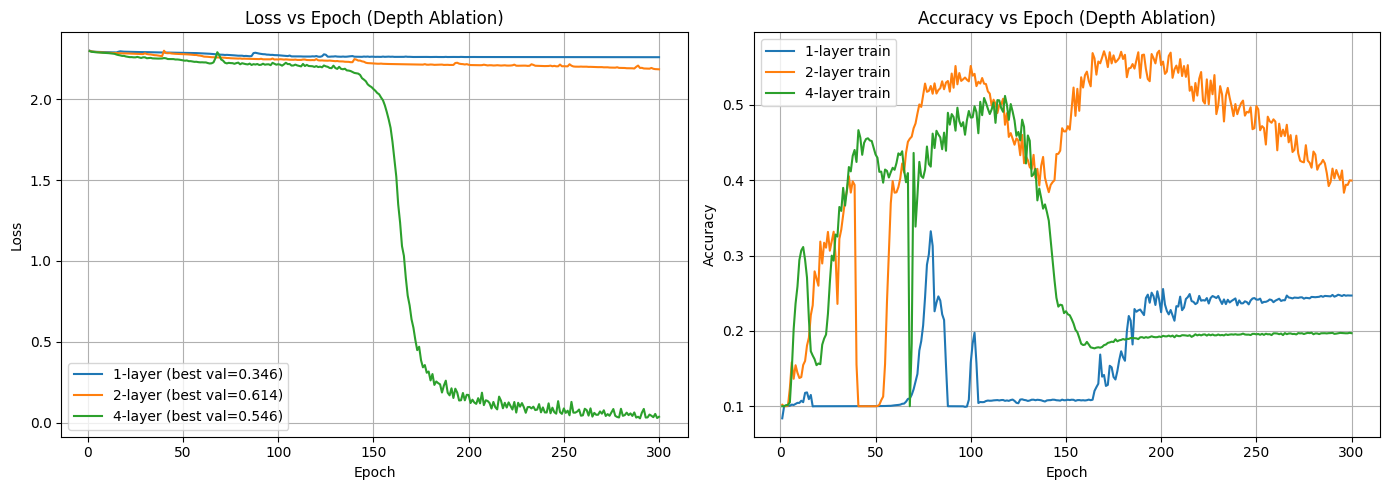

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epoch_nums = range(1, 301)

for name, (losses, _, _, best_val) in depth_results.items():
    axes[0].plot(epoch_nums, losses, label=f"{name} (best val={best_val:.3f})")
axes[0].set_title("Loss vs Epoch (Depth Ablation)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

for name, (_, accuracies, _, _) in depth_results.items():
    axes[1].plot(epoch_nums, accuracies, label=f"{name} train")
axes[1].set_title("Accuracy vs Epoch (Depth Ablation)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

**Convergence** - 1-layer and 2-layer converges most smoothly and stably. 4-layer converges early and aggressively (loss drops to ~0.05 by epoch 200) but this is, yet again, a phenomenon of confidence without correctness. 

**Expressiveness** - 2-layer peaks at 61.4%. 1-layer, which peaked at 34.6%, is underexpressive since a single round of attention can identify min/max anchors but can't do the second-stage pairwise comparisons needed to assign ranks. 4-layer, which peaked at 54.6%, is theoretically most expressive since it has more capabilities and more parameters, but it could be that the dataset is simply not complex enough for it.

**Overfitting** - Overfitting is clearly observed in the 4-layer model, as its loss collapses to near zero which accuracy is only 54.6%. 1-layer and 2-layer show no sign of overfitting since their capacity matches the task complexity.